# CCS3356 – Sentiment Analysis of Customer Reviews
## Member 01 – B Premnath (CIT-24-01-0241)
**ML Model:** Random Forest Classifier (TF-IDF features)
**DL Model:** LSTM (Long Short-Term Memory)

**Pipeline:** Data Collection → Data Cleaning → Tokenization → Stop Word Removal → Lemmatization → TF-IDF Feature Extraction → Model Training → Evaluation


In [1]:
import sys, re, time
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_utils import load_dataset, get_split, RANDOM_STATE

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_recall_fscore_support, roc_auc_score)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


I0000 00:00:1786824955.520477    1028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786824955.597847    1028 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786824957.102234    1028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Data Collection

In [2]:
df = load_dataset('../data/1429_1.csv')
print('Shape:', df.shape)
df.head()


Shape: (34626, 6)


/home/claude/NLP-Sentiment-Analysis-Group12/notebooks/../src/data_utils.py:46: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,id,name,rating,review_text,review_title,sentiment
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...,Kindle,Positive
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...,very fast,Positive
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,Positive
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Positive
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,Positive


### Class Distribution

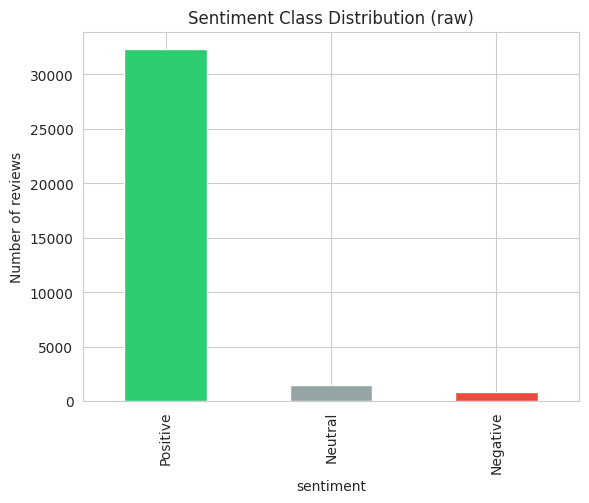

sentiment
Positive    0.933258
Neutral     0.043291
Negative    0.023451
Name: proportion, dtype: float64

In [3]:
ax = df['sentiment'].value_counts().plot(kind='bar', color=['#2ecc71','#95a5a6','#e74c3c'])
plt.title('Sentiment Class Distribution (raw)')
plt.ylabel('Number of reviews')
plt.show()
df['sentiment'].value_counts(normalize=True)


## 2. Data Cleaning
Removing URLs, HTML tags, punctuation, digits, and extra whitespace; lowercasing all text.

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head(3)


,review_text,clean_text
0,This product so far has not disappointed. My c...,this product so far has not disappointed my ch...
1,great for beginner or experienced person. Boug...,great for beginner or experienced person bough...
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet for him to use and learn on...


## 3. Tokenization, Stop Word Removal & Lemmatization

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_lemmatize(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return tokens

t0 = time.time()
df['tokens'] = df['clean_text'].apply(tokenize_lemmatize)
df['processed_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))
print(f'Preprocessing done in {time.time()-t0:.1f}s')
df[['processed_text']].head(3)


Preprocessing done in 5.2s


,processed_text
0,product far disappointed child love use like a...
1,great beginner experienced person bought gift ...
2,inexpensive tablet use learn step nabi thrille...


## 4. Word Frequency (EDA)

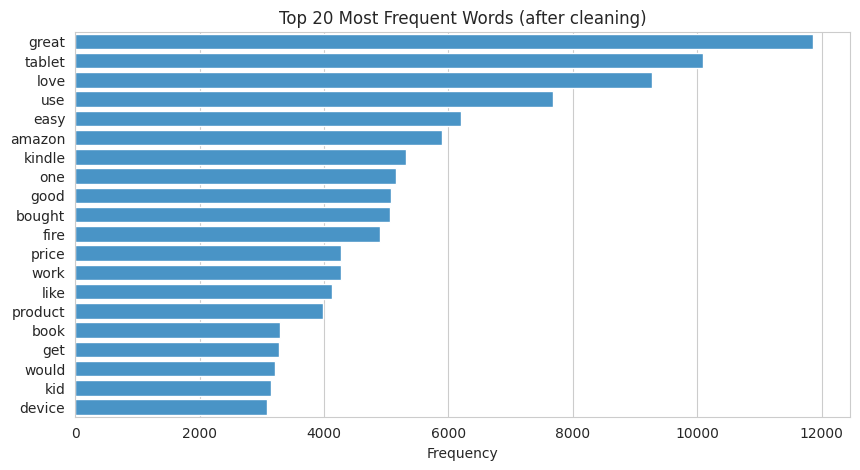

In [6]:
from collections import Counter
all_words = [w for toks in df['tokens'] for w in toks]
freq = Counter(all_words).most_common(20)
words, counts = zip(*freq)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words), color='#3498db')
plt.title('Top 20 Most Frequent Words (after cleaning)')
plt.xlabel('Frequency')
plt.show()


## 5. Train/Test Split
An 80/20 stratified split shared logic (via `data_utils.get_split`) so the ML and DL models
below are evaluated on the same holdout reviews.

In [7]:
X_train, X_test, y_train, y_test = get_split(df, text_col='processed_text', label_col='sentiment')
print(X_train.shape, X_test.shape)
y_train.value_counts()


(27700,) (6926,)


sentiment
Positive    25851
Neutral      1199
Negative      650
Name: count, dtype: int64

## 6. TF-IDF Feature Extraction

In [8]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print('TF-IDF matrix shape:', X_train_tfidf.shape)


TF-IDF matrix shape: (27700, 8000)


## 7. ML Model – Random Forest Classifier
Random Forest is robust, handles large datasets effectively, reduces overfitting through
ensemble learning, and performs well on text classification tasks.
`class_weight='balanced'` is used to counter the strong Positive-class imbalance noted
in the validation submission.

In [9]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=40, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
t0 = time.time()
rf.fit(X_train_tfidf, y_train)
print(f'Random Forest trained in {time.time()-t0:.1f}s')


Random Forest trained in 11.5s


Accuracy: 0.915102512272596
              precision    recall  f1-score   support

    Negative       0.39      0.06      0.10       162
     Neutral       0.18      0.13      0.15       300
    Positive       0.94      0.97      0.96      6464

    accuracy                           0.92      6926
   macro avg       0.50      0.39      0.40      6926
weighted avg       0.89      0.92      0.90      6926



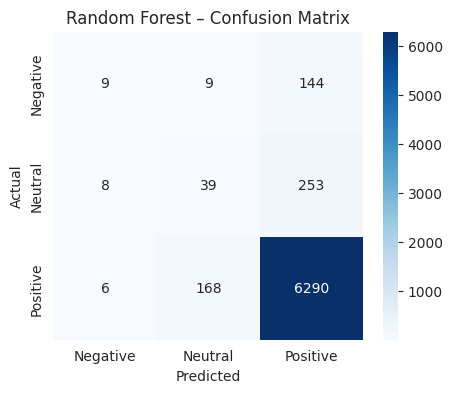

In [10]:
y_pred_rf = rf.predict(X_test_tfidf)
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('Random Forest – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## 8. DL Model – LSTM (Long Short-Term Memory)
LSTM networks are specifically designed for sequence data and can capture contextual
relationships within text, making them highly effective for sentiment analysis.

In [11]:
MAX_WORDS = 10000
MAX_LEN = 100

label_map = {'Negative':0, 'Neutral':1, 'Positive':2}
y_train_int = y_train.map(label_map).values
y_test_int = y_test.map(label_map).values
y_train_cat = to_categorical(y_train_int, num_classes=3)
y_test_cat = to_categorical(y_test_int, num_classes=3)

keras_tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)

X_train_seq = pad_sequences(keras_tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(keras_tok.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')
print(X_train_seq.shape, X_test_seq.shape)


(27700, 100) (6926, 100)


In [12]:
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train_int)
# Dampen extreme weights (sqrt) so gradient-based training doesn't over-correct
cw = np.sqrt(cw)
class_weight_dict = {i: w for i, w in enumerate(cw)}
print(class_weight_dict)

history = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.1,
    epochs=4, batch_size=128,
    class_weight=class_weight_dict,
    verbose=2
)


{0: np.float64(3.768969117030306), 1: np.float64(2.7750426716182575), 2: np.float64(0.5976412746473386)}


Epoch 1/4


195/195 - 30s - 151ms/step - accuracy: 0.9282 - loss: 0.6218 - val_accuracy: 0.9357 - val_loss: 0.4903


Epoch 2/4


195/195 - 40s - 207ms/step - accuracy: 0.9330 - loss: 0.6038 - val_accuracy: 0.9357 - val_loss: 0.4666


Epoch 3/4


195/195 - 41s - 212ms/step - accuracy: 0.9330 - loss: 0.6044 - val_accuracy: 0.9357 - val_loss: 0.4717


Epoch 4/4


195/195 - 41s - 208ms/step - accuracy: 0.9333 - loss: 0.5982 - val_accuracy: 0.9354 - val_loss: 0.4556


Accuracy: 0.9332948310713255
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       162
     Neutral       0.00      0.00      0.00       300
    Positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87      0.93      0.90      6926



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


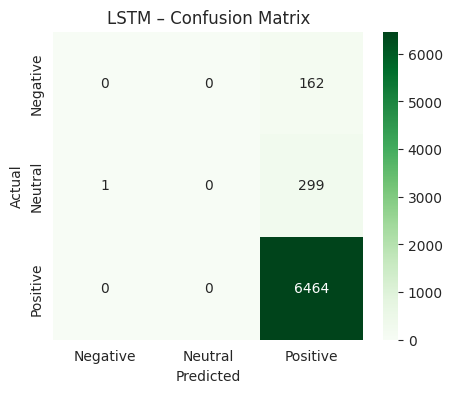

In [14]:
y_pred_lstm_prob = lstm_model.predict(X_test_seq, verbose=0)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)
inv_label_map = {v:k for k,v in label_map.items()}
y_pred_lstm_labels = [inv_label_map[i] for i in y_pred_lstm]

print('Accuracy:', accuracy_score(y_test, y_pred_lstm_labels))
print(classification_report(y_test, y_pred_lstm_labels))

cm2 = confusion_matrix(y_test, y_pred_lstm_labels, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('LSTM – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## 9. Model Comparison – Random Forest vs LSTM

In [15]:
def macro_scores(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return accuracy_score(y_true, y_pred), p, r, f1

acc_rf, p_rf, r_rf, f1_rf = macro_scores(y_test, y_pred_rf)
acc_lstm, p_lstm, r_lstm, f1_lstm = macro_scores(y_test, y_pred_lstm_labels)

comparison = pd.DataFrame({
    'Model': ['Random Forest (ML)', 'LSTM (DL)'],
    'Accuracy': [acc_rf, acc_lstm],
    'Macro Precision': [p_rf, p_lstm],
    'Macro Recall': [r_rf, r_lstm],
    'Macro F1': [f1_rf, f1_lstm],
})
comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest (ML),0.915103,0.504164,0.386212,0.401680
1,LSTM (DL),0.933295,0.311143,0.333333,0.321856


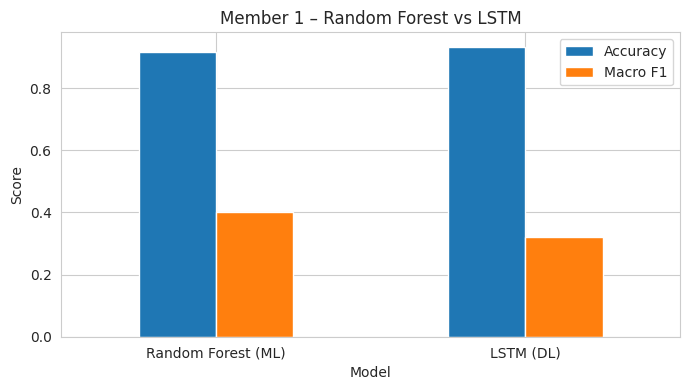

In [16]:
comparison.set_index('Model')[['Accuracy','Macro F1']].plot(kind='bar', figsize=(7,4))
plt.title('Member 1 – Random Forest vs LSTM')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Save Models

In [17]:
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/premnath_random_forest.joblib')
joblib.dump(tfidf, '../models/premnath_tfidf_vectorizer.joblib')
lstm_model.save('../models/premnath_lstm_model.keras')
import pickle
with open('../models/premnath_keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tok, f)
print('Saved: random_forest, tfidf_vectorizer, lstm_model, keras_tokenizer')


Saved: random_forest, tfidf_vectorizer, lstm_model, keras_tokenizer


## Contribution Summary (Premnath)
- Data preprocessing (cleaning, tokenization, stop-word removal, lemmatization)
- TF-IDF feature extraction
- Random Forest implementation
- LSTM implementation
- Performance evaluation
- Documentation support
